In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Load the data
df = pd.read_csv('train.csv')

# 2. Select variables: Area, Bedrooms, Bathrooms
X = df[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = df['SalePrice']

# 3. Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Results
print(f"Model Training Complete!")
print(f"Accuracy Score: {model.score(X_test, y_test) * 100:.2f}%")

Model Training Complete!
Accuracy Score: 63.41%


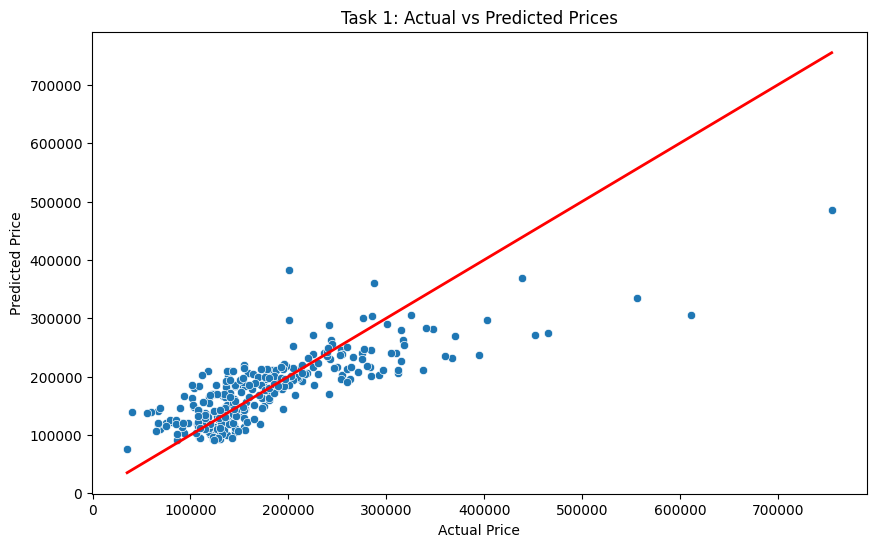

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the visual proof
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=model.predict(X_test))
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Task 1: Actual vs Predicted Prices')
plt.show()

In [17]:
import gradio as gr
import pandas as pd

# 1. The Prediction Function
def predict_price(sq_ft, bedrooms, bathrooms):
    # This must match your model columns exactly
    input_data = pd.DataFrame([[sq_ft, bedrooms, bathrooms]],
                             columns=['GrLivArea', 'BedroomAbvGr', 'FullBath'])
    prediction = model.predict(input_data)[0]
    return f"Estimated Price: ${max(0, prediction):,.2f}"

# 2. The Interface (Fixed Sliders)
demo = gr.Interface(
    fn=predict_price,
    inputs=[
        gr.Slider(minimum=500, maximum=5000, value=1500, step=50, label="Square Footage (sqft)"),
        gr.Slider(minimum=1, maximum=6, value=3, step=1, label="Number of Bedrooms"),
        gr.Slider(minimum=1, maximum=4, value=2, step=1, label="Number of Bathrooms") # Added range and step
    ],
    outputs=gr.Textbox(label="Predicted House Price"),
    title=" House Price Predictor",
    description="Adjust the sliders to see how size and rooms change the house price."
)

# 3. Launch
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8a70d65af839818656.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
